# Training a Foreground Segmentation Tool with DINOv3



### Setup

Let's start by loading some pre-requisites and checking the DINOv3 repository location:

In [5]:
# @title 1. Install Dependencies & Imports
!pip install -q roboflow torch torchvision tqdm matplotlib scikit-learn wandb torchmetrics

import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel
from google.colab import userdata, drive
from tqdm.notebook import tqdm
import random

print(" All dependencies installed and imported!")

 All dependencies installed and imported!


In [6]:
# @title 2. Mount Google Drive & Setup Paths
from google.colab import drive
import os

drive.mount('/content/drive')
print("✅ Google Drive mounted!")

# Define save paths for model weights
SAVED_WEIGHTS_PATH = '/content/drive/MyDrive/seg_head_weights.pth'
LOCAL_WEIGHTS_PATH = './seg_head_weights_local.pth'

# Create checkpoint directory (Updated to DINOv3)
checkpoint_dir = "/content/drive/MyDrive/DINOv3_Checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"Checkpoint directory: {checkpoint_dir}")

# Define Dataset Path directly to your EOR-Database folder
DATASET_PATH = '/content/drive/MyDrive/EOR-Database-MOT.v5-mot-rect-5-super-repairs-streched.coco-segmentation'
print(f"Dataset path set to: {DATASET_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted!
Checkpoint directory: /content/drive/MyDrive/DINOv3_Checkpoints
Dataset path set to: /content/drive/MyDrive/EOR-Database-MOT.v5-mot-rect-5-super-repairs-streched.coco-segmentation


In [7]:
# @title 2.5 Weights & Biases Setup with Secret Key
import wandb

# Initialize wandb (optional - you can skip if you don't want wandb)
USE_WANDB = True  # Set to False if you don't want wandb logging
wandb_run = None

if USE_WANDB:
    try:
        # Get wandb API key from Colab secrets
        wandb_api_key = userdata.get('WANDB_API')
        wandb.login(key=wandb_api_key)
        print(" WandB API key retrieved and logged in!")

        # Start a new run
        wandb.init(
            project="dino-foreground-segmentation",
            name="tao-dataset-training",
            config={
                "learning_rate": 1e-3,
                "batch_size": 1,
                "img_size": 448,
                "buffer_size": 50,
                "epochs": 1,
                "model": "DINOv3-ViT-L",
                "dataset": "TAO-Bin-Mask",
                "device" : torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                "optimizer": "Adam",
                "loss": "CrossEntropy"
            },
            resume="allow"
        )
        print("Weights & Biases initialized and run started!")

    except Exception as e:
        print(f" Error setting up WandB: {e}")
        print("  WandB logging disabled. Check your WANDB_API_KEY in secrets.")
        USE_WANDB = False
        wandb = None  # Set to None to avoid errors later
else:
    print("  WandB logging disabled by setting USE_WANDB=False.")
    wandb = None  # Set to None to avoid errors later

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: faqihahsyazwani23 (faqihahsyazwani23-university-malaya-medical-centre) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


 WandB API key retrieved and logged in!


Weights & Biases initialized and run started!


### Model & Head

Let's load the DINOv3 model. For this notebook, we will be using the ViT-L model, but if you have more or less hardware constraints, you can easily load any other DINOv3 model!

In [8]:
# @title 3. Load DINOv3 Model
try:
    hf_token = userdata.get('HF_TOKEN') # Make sure you added 'HF_TOKEN' to Colab Secrets!
    print("Token retrieved.")
except Exception as e:
    print("ERROR: Add 'HF_TOKEN' to the Key Icon on the left sidebar first!")
    raise e

# 2. Load DINOv3
print("Loading DINOv3 (ViT-L)...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_id = "facebook/dinov3-vitl16-pretrain-lvd1689m"

# AutoModel handles the download automatically using your token
model = AutoModel.from_pretrained(model_id, token=hf_token, trust_remote_code=True)
model.to(device)
model.eval()

# Freeze the backbone
for param in model.parameters():
    param.requires_grad = False

print(f"Model loaded and frozen!")

Token retrieved.
Loading DINOv3 (ViT-L)...


config.json:   0%|          | 0.00/745 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.21G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

Model loaded and frozen!


In [9]:
# @title 4. Define Multi-Class Segmentation Head
NUM_CLASSES = 6 # Update this based on how many defect types you have + 1 for Background

class SegmentationHead(nn.Module):
    def __init__(self, input_dim=1024, num_classes=NUM_CLASSES):
        super().__init__()
        self.head = nn.Conv2d(input_dim, num_classes, kernel_size=1)

    def forward(self, x):
        return self.head(x)

# Initialize Head with 1024 dimensions and NUM_CLASSES output channels
seg_head = SegmentationHead(input_dim=1024, num_classes=NUM_CLASSES).to(device)
print(f"✅ Multi-Class Segmentation Head Initialized for {NUM_CLASSES} classes.")

✅ Multi-Class Segmentation Head Initialized for 6 classes.


In [10]:
# @title 5. Feature Extraction Helper (For Hugging Face DINO Models)

def extract_dino_features(model, image_tensor):
    """
    Input: image_tensor (Batch, 3, Height, Width)
    Output: features (Batch, Hidden_Dim, H_grid, W_grid)
    """
    B, C, H, W = image_tensor.shape

    # 1. Update to Patch Size 16 for vitl16
    patch_size = 16
    H_new = (H // patch_size) * patch_size
    W_new = (W // patch_size) * patch_size

    if H != H_new or W != W_new:
        image_tensor = F.interpolate(image_tensor, size=(H_new, W_new), mode='bilinear', align_corners=False)

    with torch.no_grad():
        outputs = model(image_tensor, output_hidden_states=True)
        last_hidden_state = outputs.last_hidden_state

        # 2. Calculate true spatial grid dimensions (28x28 for a 448 image)
        H_grid = H_new // patch_size
        W_grid = W_new // patch_size
        num_spatial_tokens = H_grid * W_grid

        # 3. Extract ONLY the spatial patch tokens from the end of the sequence
        # This safely ignores the [CLS] token and the 4 Register tokens
        patch_tokens = last_hidden_state[:, -num_spatial_tokens:, :]

        # 4. Reshape Sequence -> Spatial Grid
        # Using explicit dimensions instead of -1 to prevent silent reshaping bugs
        hidden_dim = patch_tokens.shape[-1]
        features = patch_tokens.permute(0, 2, 1).reshape(B, hidden_dim, H_grid, W_grid)

    return features

print("Feature Extractor Helper defined.")

Feature Extractor Helper defined.


In [11]:
# @title Save/Load Functions (utilities only — no auto-load)
def save_model(model, path):
    torch.save(model.state_dict(), path)
    print(f"Model saved to: {path}")

def load_model(model, path):
    if os.path.exists(path):
        try:
            model.load_state_dict(torch.load(path)); print(f"Model loaded from: {path}"); return True
        except Exception as e:
            print(f"Error loading: {e}"); return False
    print(f"No model found at: {path}"); return False

print("Save/load utilities defined.")
# NOTE: auto-load removed so this notebook ALWAYS trains seg_head from scratch.


Save/load utilities defined.


In [12]:
# @title Data Loading (Multi-Class COCO Parser)
import os
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
from pycocotools.coco import COCO

img_transform = T.Compose([
    T.Resize((448, 448)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

class COCOMultiClassDataset(Dataset):
    def __init__(self, root_dir, split='train', img_transform=None):
        self.split_dir = os.path.join(root_dir, split)
        self.coco = COCO(os.path.join(self.split_dir, '_annotations.coco.json'))
        self.image_ids = list(self.coco.imgs.keys())
        self.img_transform = img_transform

    def __len__(self): return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        image = Image.open(os.path.join(self.split_dir, img_info['file_name'])).convert('RGB')

        anns = self.coco.loadAnns(self.coco.getAnnIds(imgIds=img_id))
        mask = np.zeros((img_info['height'], img_info['width']))

        # --- CLASS-IL UPGRADE: PAINT SPECIFIC CATEGORY IDs ---
        for ann in anns:
            cat_id = ann['category_id']
            ann_mask = self.coco.annToMask(ann)
            # Assign the category ID to only the defect pixels (0 remains background)
            mask[ann_mask > 0] = cat_id

        if self.img_transform: image = self.img_transform(image)
        mask_tensor = torch.tensor(mask, dtype=torch.long)

        return image, mask_tensor

# Initialize
DATASET_PATH = '/content/drive/MyDrive/EOR-Database-MOT.v5-mot-rect-5-super-repairs-streched.coco-segmentation'
full_train = COCOMultiClassDataset(DATASET_PATH, split='train', img_transform=img_transform)
full_test = COCOMultiClassDataset(DATASET_PATH, split='valid', img_transform=img_transform)

# ==========================================
# TRUE CLASS-INCREMENTAL SPLIT (5 TASKS)
# ==========================================
print(f"Filtering dataset by 5 strict defect categories...")

def create_task_loader(dataset, target_category, batch_size=4, shuffle=True):
    """Filters the dataset to only include images containing the target defect category."""
    valid_indices = []
    for idx, img_id in enumerate(dataset.image_ids):
        anns = dataset.coco.loadAnns(dataset.coco.getAnnIds(imgIds=img_id))
        # If the image contains the target defect, add it to this task
        if any(ann['category_id'] == target_category for ann in anns):
            valid_indices.append(idx)

    task_subset = torch.utils.data.Subset(dataset, valid_indices)
    return DataLoader(task_subset, batch_size=batch_size, shuffle=shuffle)

# Generate exactly 5 tasks based on Category IDs 1 through 5
task_train_loaders = []
task_test_loaders = []

for category_id in range(1, 6):
    train_dl = create_task_loader(full_train, target_category=category_id, shuffle=True)
    test_dl = create_task_loader(full_test, target_category=category_id, shuffle=False)

    task_train_loaders.append(train_dl)
    task_test_loaders.append(test_dl)

    print(f"Task {category_id}: Created with {len(train_dl.dataset)} train images.")

print("✅ DataLoaders are officially Class-Incremental and match the benchmark!")

# Dataset totals (unique images per split)
print("Train images:", len(full_train), "| Validation images:", len(full_test))


loading annotations into memory...
Done (t=47.74s)
creating index...
index created!
loading annotations into memory...
Done (t=5.77s)
creating index...
index created!
Filtering dataset by 5 strict defect categories...
Task 1: Created with 2007 train images.
Task 2: Created with 552 train images.
Task 3: Created with 2801 train images.
Task 4: Created with 662 train images.
Task 5: Created with 2076 train images.
✅ DataLoaders are officially Class-Incremental and match the benchmark!
Train images: 11133 | Validation images: 1717


In [13]:
# @title 11. Phase 2: Meta-Experience Replay (MER) — full metrics (AA/F/BWT/FWT) + cost

import time, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from tqdm import tqdm
from torchmetrics.classification import MulticlassJaccardIndex

NUM_CLASSES = 6; NUM_EPOCHS = 10; LR = 1e-3; GPU_TDP_W = 300
ALPHA = 0.5; BETA = 0.5; BUFFER_SIZE = 500; REPLAY_BS = 4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42); np.random.seed(42)

class CostTracker:
    def __init__(self, tdp=GPU_TDP_W): self.tdp=tdp; self._cc=None
    def start(self):
        self.t0=time.time()
        try:
            from codecarbon import EmissionsTracker
            self._cc=EmissionsTracker(measure_power_secs=15, log_level="error", save_to_file=False); self._cc.start()
        except Exception: self._cc=None
    def stop(self):
        self.elapsed_s=time.time()-self.t0; self.energy_kwh=None; self.estimated=True
        if self._cc is not None:
            try: self._cc.stop(); self.energy_kwh=float(self._cc.final_emissions_data.energy_consumed); self.estimated=False
            except Exception: self.energy_kwh=None
        if self.energy_kwh is None: self.energy_kwh=self.tdp*self.elapsed_s/3600.0/1000.0
        return self.elapsed_s, self.energy_kwh

class MultiClassDiceLoss(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, smooth=1e-6): super().__init__(); self.num_classes=num_classes; self.smooth=smooth
    def forward(self, logits, true_masks):
        probs=torch.softmax(logits,dim=1)
        if true_masks.dim()==4: true_masks=true_masks.squeeze(1)
        oh=F.one_hot(true_masks,num_classes=self.num_classes).permute(0,3,1,2).float()
        dl=0.0
        for c in range(1,self.num_classes):
            p,t=probs[:,c],oh[:,c]; inter=(p*t).sum(dim=(1,2)); union=p.sum(dim=(1,2))+t.sum(dim=(1,2))
            dl+=(1.0-((2*inter+self.smooth)/(union+self.smooth)).mean())
        return dl/(self.num_classes-1)

def _prep(masks,tH,tW):
    mi=masks.float()
    if mi.dim()==3: mi=mi.unsqueeze(1)
    elif mi.dim()==2: mi=mi.unsqueeze(0).unsqueeze(0)
    ms=F.interpolate(mi,size=(tH,tW),mode="nearest").squeeze().long()
    return ms.unsqueeze(0) if ms.dim()==2 else ms

def evaluate_one(model,seg_head,dl,device):
    iou=MulticlassJaccardIndex(num_classes=NUM_CLASSES,average="macro",ignore_index=0).to(device); seg_head.eval()
    with torch.no_grad():
        for imgs,masks in dl:
            imgs,masks=imgs.to(device),masks.long().to(device); feats=extract_dino_features(model,imgs)
            iou.update(torch.argmax(seg_head(feats),dim=1),_prep(masks,feats.shape[2],feats.shape[3]))
    return iou.compute().item()

def evaluate_all(model,seg_head,loaders,device):
    return np.array([evaluate_one(model,seg_head,dl,device) for dl in loaders])

def compute_cl_metrics(R,baseline):
    T=R.shape[0]; AA=float(R[-1].mean())
    F_=float(np.mean([R[:-1,j].max()-R[-1,j] for j in range(T-1)]))
    BWT=float(np.mean([R[-1,j]-R[j,j] for j in range(T-1)]))
    FWT=float(np.mean([R[j-1,j]-baseline[j] for j in range(1,T)]))
    return AA,F_,BWT,FWT

class ReplayBuffer:
    def __init__(s,size=BUFFER_SIZE): s.size=size; s.buf=[]; s.seen=0
    def add(s,feat,mask):
        it=(feat.detach().cpu(),mask.detach().cpu())
        if len(s.buf)<s.size: s.buf.append(it)
        else:
            j=np.random.randint(0,s.seen+1)
            if j<s.size: s.buf[j]=it
        s.seen+=1
    def get(s,bs=REPLAY_BS):
        if len(s.buf)<bs: return None,None
        idx=np.random.choice(len(s.buf),bs,replace=False)
        return torch.stack([s.buf[i][0] for i in idx]).to(device), torch.stack([s.buf[i][1] for i in idx]).to(device)

class DERBuffer:
    def __init__(s,size=BUFFER_SIZE): s.size=size; s.buf=[]; s.pos=0
    def add(s,feat,mask,logit):
        it=(feat.detach().cpu(),mask.detach().cpu(),logit.detach().cpu())
        if len(s.buf)<s.size: s.buf.append(it)
        else: s.buf[s.pos]=it; s.pos=(s.pos+1)%s.size
    def get(s,bs=REPLAY_BS):
        if len(s.buf)<bs: return None,None,None
        idx=np.random.choice(len(s.buf),bs,replace=False)
        return (torch.stack([s.buf[i][0] for i in idx]).to(device),
                torch.stack([s.buf[i][1] for i in idx]).to(device),
                torch.stack([s.buf[i][2] for i in idx]).to(device))

class SynapticIntelligence:
    def __init__(self, named_params, c=0.5, xi=1.0):
        self.c,self.xi=c,xi
        self.params={n:p for n,p in named_params if p.requires_grad}
        self.W={n:torch.zeros_like(p) for n,p in self.params.items()}
        self.Omega={n:torch.zeros_like(p) for n,p in self.params.items()}
        self.theta_star={n:p.detach().clone() for n,p in self.params.items()}
        self.theta_start={n:p.detach().clone() for n,p in self.params.items()}
    def penalty(self):
        loss=0.0
        for n,p in self.params.items(): loss=loss+(self.Omega[n]*(p-self.theta_star[n])**2).sum()
        return self.c*loss
    def begin_task(self):
        for n,p in self.params.items(): self.theta_start[n]=p.detach().clone(); self.W[n].zero_()
    @torch.no_grad()
    def accumulate(self, old):
        for n,p in self.params.items():
            if p.grad is not None: self.W[n].add_(-p.grad.detach()*(p.detach()-old[n]))
    @torch.no_grad()
    def end_task(self):
        for n,p in self.params.items():
            d=p.detach()-self.theta_start[n]; self.Omega[n].add_(self.W[n]/(d**2+self.xi)); self.theta_star[n]=p.detach().clone()

num_tasks=len(task_train_loaders)
R=np.zeros((num_tasks,num_tasks))
criterion=MultiClassDiceLoss(num_classes=NUM_CLASSES)
optimizer=torch.optim.Adam(seg_head.parameters(), lr=LR)

buffer=ReplayBuffer(BUFFER_SIZE); S_BATCHES=3; GAMMA=0.1
baseline=evaluate_all(model,seg_head,task_test_loaders,device)
print("Random-init baseline IoU per task:", np.round(baseline,4).tolist())
cost=CostTracker(); cost.start()
for task_id in range(num_tasks):
    print(f"\n{'='*60}\n TASK {task_id+1}/{num_tasks} - Meta-Experience Replay (MER)\n{'='*60}")
    train_dl=task_train_loaders[task_id]
    for epoch in range(NUM_EPOCHS):
        seg_head.train(); running,n=0.0,0
        for imgs,masks in tqdm(train_dl, desc=f"Task {task_id+1} - Epoch {epoch+1}"):
            imgs,masks=imgs.to(device),masks.long().to(device)
            feats=extract_dino_features(model,imgs); ms=_prep(masks,feats.shape[2],feats.shape[3])
            weights_before={n:p.detach().clone() for n,p in seg_head.named_parameters()}
            batches=[(feats,ms)]
            for _ in range(S_BATCHES):
                bf,bm=buffer.get()
                if bf is not None: batches.append((bf,bm))
            for bx,by in batches:
                optimizer.zero_grad(); l=criterion(seg_head(bx),by); l.backward(); optimizer.step()
            with torch.no_grad():
                for nm,p in seg_head.named_parameters(): p.data=weights_before[nm]+GAMMA*(p.data-weights_before[nm])
            for i in range(feats.size(0)): buffer.add(feats[i],ms[i])
            loss_val=l.item()
            running+=loss_val; n+=1
        print(f"  Epoch {epoch+1}: Loss={running/max(n,1):.4f}")
    R[task_id]=evaluate_all(model,seg_head,task_test_loaders,device)
    print(f"  IoU on all tasks now: {np.round(R[task_id],4).tolist()}")
elapsed_s,energy_kwh=cost.stop()

AA,F_,BWT,FWT=compute_cl_metrics(R,baseline)
print("\n"+"="*60+"\n FINAL Meta-Experience Replay (MER) METRICS\n"+"="*60)
print(f"Average Accuracy (AA):   {AA:.4f}")
print(f"Forgetting (F):          {F_:.4f}   (lower is better)")
print(f"Backward Transfer (BWT): {BWT:.4f}")
print(f"Forward Transfer (FWT):  {FWT:.4f}   (positive = earlier tasks helped later)")
print(f"Total training time:     {elapsed_s:.1f} s  ({elapsed_s/60:.2f} min)")
print(f"Energy consumed:         {energy_kwh:.5f} kWh"+("  (estimated)" if cost.estimated else "  (measured)"))
print("\nFull Accuracy Matrix R[i,j] (row = after task i, col = task j):")
print("        "+"".join(f"T{j+1:>7}" for j in range(num_tasks)))
for i in range(num_tasks):
    print(f"After T{i+1}:"+"".join(f"{R[i,j]:8.3f}" for j in range(num_tasks)))
np.save("R_matrix_mer.npy",R); np.save("baseline_mer.npy",baseline)
torch.save(seg_head.state_dict(),"phase2_mer_weights.pth")
print("\nSaved: R_matrix_mer.npy, baseline_mer.npy, phase2_mer_weights.pth")


Random-init baseline IoU per task: [0.0711, 0.0302, 0.0879, 0.0845, 0.0532]

 TASK 1/5 - Meta-Experience Replay (MER)


Task 1 - Epoch 1: 100%|██████████| 502/502 [20:25<00:00,  2.44s/it]


  Epoch 1: Loss=0.8480


Task 1 - Epoch 2: 100%|██████████| 502/502 [02:17<00:00,  3.65it/s]


  Epoch 2: Loss=0.8197


...

  Epoch 8: Loss=0.6610


Task 5 - Epoch 9: 100%|██████████| 519/519 [02:22<00:00,  3.65it/s]


  Epoch 9: Loss=0.6603


Task 5 - Epoch 10: 100%|██████████| 519/519 [02:22<00:00,  3.65it/s]


  Epoch 10: Loss=0.6636
  IoU on all tasks now: [0.5051, 0.0235, 0.2979, 0.6353, 0.4034]

 FINAL Meta-Experience Replay (MER) METRICS
Average Accuracy (AA):   0.3730
Forgetting (F):          0.0187   (lower is better)
Backward Transfer (BWT): -0.0187
Forward Transfer (FWT):  0.2158   (positive = earlier tasks helped later)
Total training time:     9733.9 s  (162.23 min)
Energy consumed:         0.81116 kWh  (estimated)

Full Accuracy Matrix R[i,j] (row = after task i, col = task j):
        T      1T      2T      3T      4T      5
After T1:   0.507   0.032   0.164   0.537   0.380
After T2:   0.502   0.035   0.166   0.532   0.383
After T3:   0.477   0.033   0.329   0.594   0.358
After T4:   0.460   0.030   0.315   0.667   0.327
After T5:   0.505   0.023   0.298   0.635   0.403

Saved: R_matrix_mer.npy, baseline_mer.npy, phase2_mer_weights.pth


In [14]:
# @title 12. Inference Function
def predict_segmentation(image_pil):
    """Run segmentation on a PIL image"""
    with torch.no_grad():
        seg_head.eval()

        # Transform image
        img_tensor = img_transform(image_pil).unsqueeze(0).to(device)

        # Extract features and predict
        features = extract_dino_features(model, img_tensor)
        logits = seg_head(features)

        # Get probabilities and prediction
        probs = torch.softmax(logits, dim=1)
        pred_mask = torch.argmax(probs, dim=1).squeeze().cpu().numpy()

        # Resize to original size
        original_size = image_pil.size[::-1]  # (height, width)
        pred_mask_resized = np.array(Image.fromarray(pred_mask.astype(np.uint8))
                                     .resize(original_size, Image.NEAREST))

        return pred_mask_resized

print("Inference function defined.")

Inference function defined.


Running multi-class batch inference on 5 random samples...


/tmp/ipykernel_2058/2432282097.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', 6)


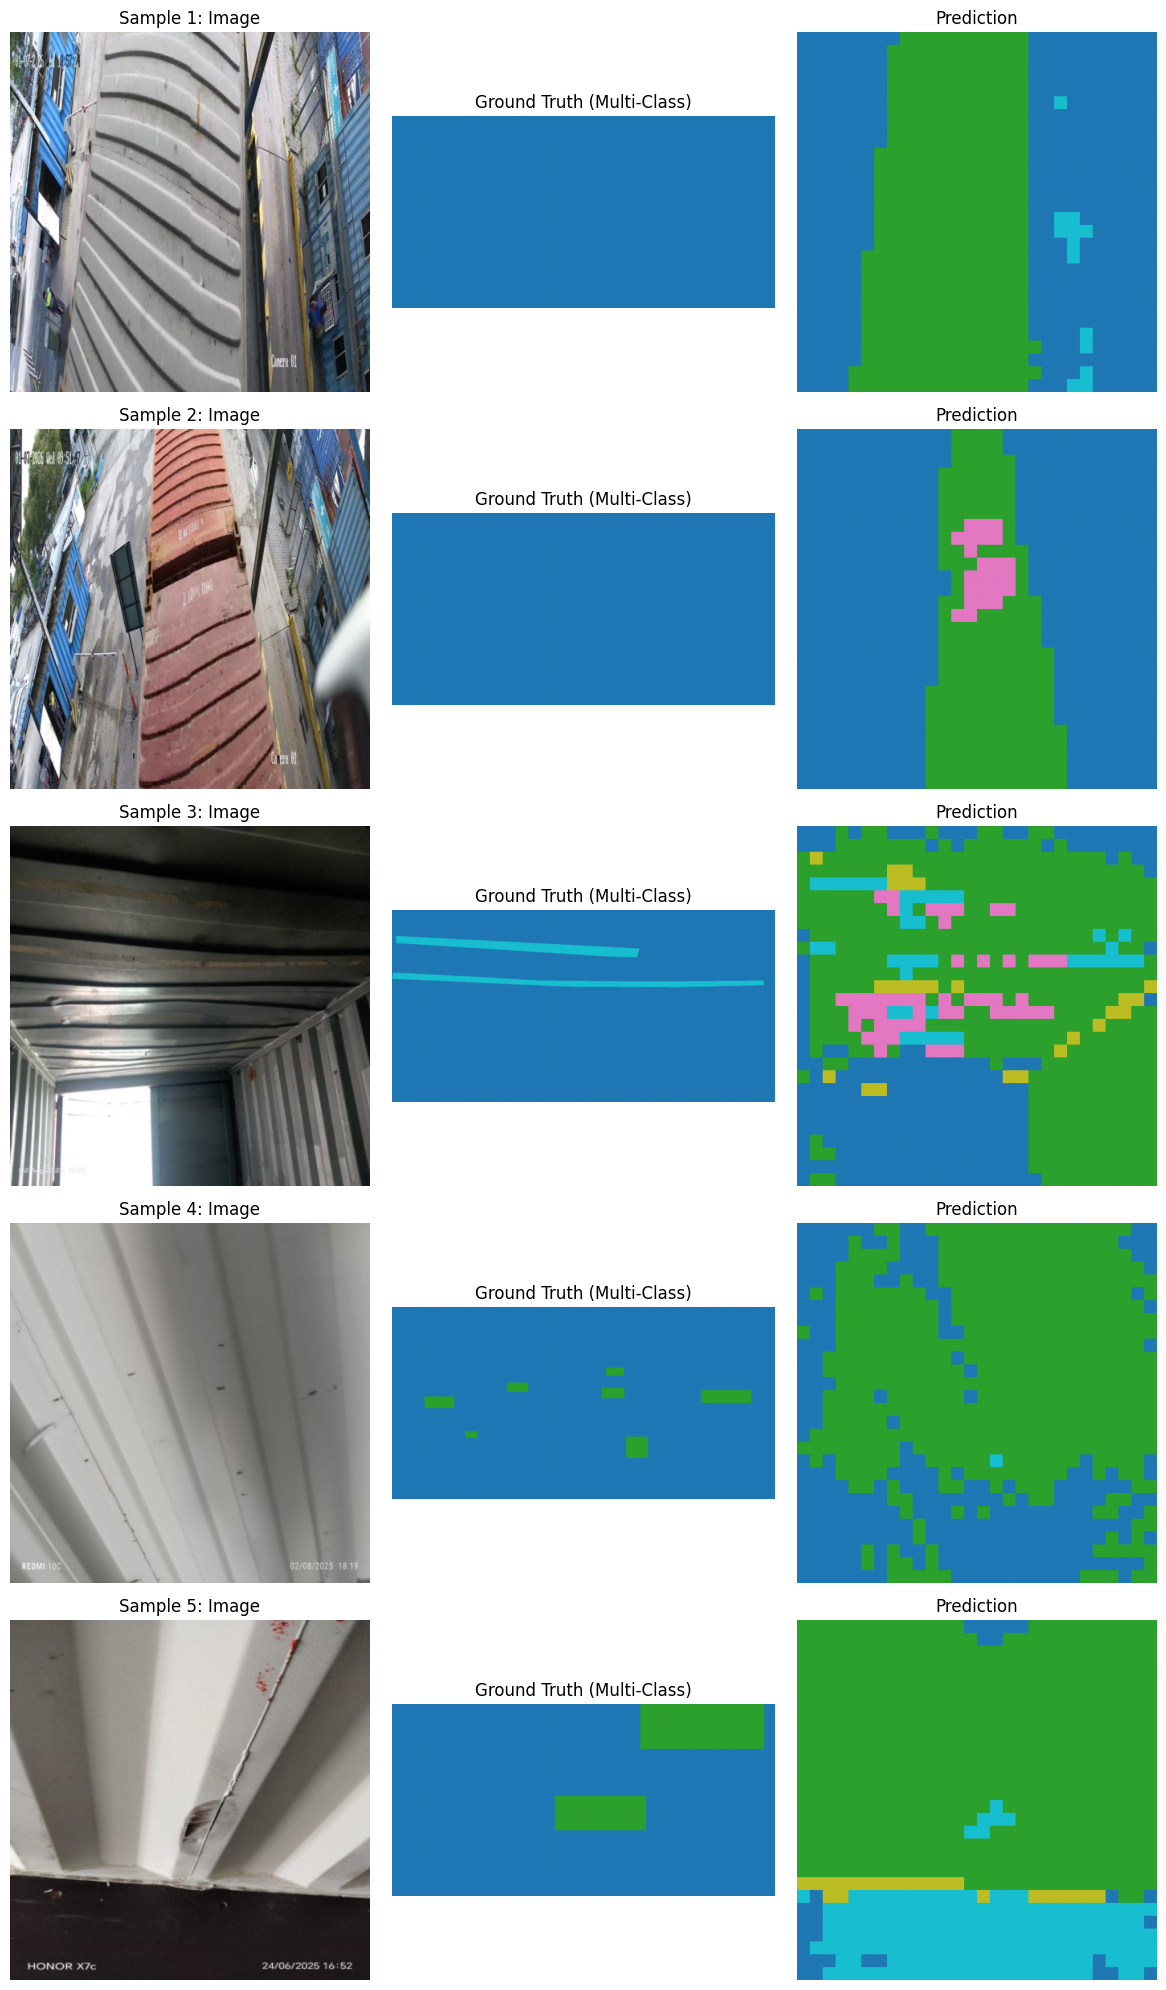

In [15]:
# @title 14. Batch Inference Demo
import random
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

print("Running multi-class batch inference on 5 random samples...")

fig, axes = plt.subplots(5, 3, figsize=(12, 20))

# Use a discrete colormap suitable for 6 distinct classes
cmap = plt.cm.get_cmap('tab10', 6)

for i in range(5):
    # Get random sample
    idx = random.randint(0, len(full_test) - 1)
    img_pil, mask = full_test[idx]

    # Convert for display
    img_display = img_pil.permute(1, 2, 0).numpy()
    img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_display = np.clip(img_display, 0, 1)

    # Get prediction
    pred = predict_segmentation(Image.fromarray((img_display * 255).astype(np.uint8)))

    # Plot - use 2D indexing
    axes[i, 0].imshow(img_display)
    axes[i, 0].set_title(f"Sample {i+1}: Image")
    axes[i, 0].axis('off')

    # Remove the > 0 squashing step and apply multi-class colormap
    axes[i, 1].imshow(mask.squeeze().numpy(), cmap=cmap, vmin=0, vmax=5)
    axes[i, 1].set_title("Ground Truth (Multi-Class)")
    axes[i, 1].axis('off')

    # Apply multi-class colormap to predictions
    axes[i, 2].imshow(pred, cmap=cmap, vmin=0, vmax=5)
    axes[i, 2].set_title("Prediction")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()